In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


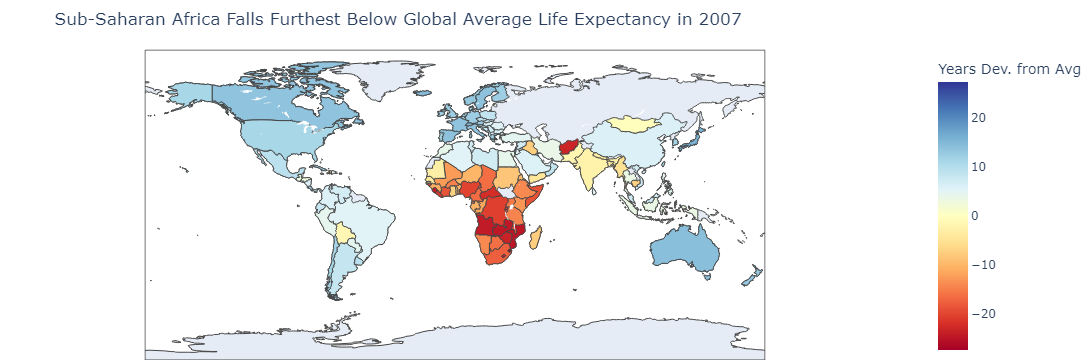

In [5]:
# Task 1

df_gapminder = px.data.gapminder()
gm_2007 = df_gapminder[df_gapminder['year'] == 2007].copy()

global_mean_life_exp = gm_2007['lifeExp'].mean()
gm_2007['lifeExp_deviation'] = gm_2007['lifeExp'] - global_mean_life_exp

fig1 = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="lifeExp_deviation",
    hover_name="country",
    hover_data={
        "iso_alpha": False,               
        "lifeExp": True,                  
        "lifeExp_deviation": ":.2f"       
    },
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0,
    labels={
        "lifeExp_deviation": "Deviation from Average (Years)",
        "lifeExp": "Life Expectancy (Years)"
    },
    title="Sub-Saharan Africa Falls Furthest Below Global Average Life Expectancy in 2007"
)

fig1.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Years Dev. from Avg")
)

fig1.show()

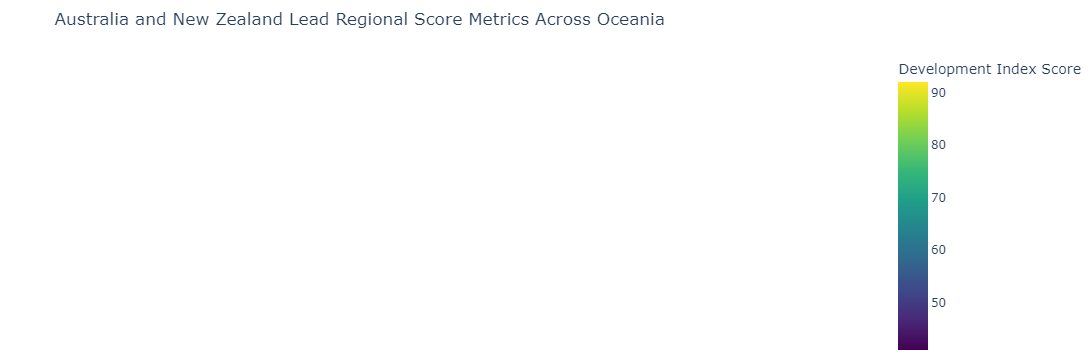

In [4]:
# Task 2

import json
import pandas as pd
import plotly.express as px

geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world_geojson = json.loads(pd.read_json(geojson_url).to_json())

oceania_data = {
    "country_iso": ["AUS", "NZL", "PNG", "FJI", "SLB", "VUT", "NCL"],
    "country_name": ["Australia", "New Zealand", "Papua New Guinea", "Fiji", "Solomon Islands", "Vanuatu", "New Caledonia"],
    "regional_score": [92, 88, 45, 58, 41, 49, 65]
}
df_oceania = pd.DataFrame(oceania_data)

fig2 = px.choropleth(
    df_oceania,
    geojson=world_geojson,
    locations="country_iso",
    featureidkey="id",  
    color="regional_score",
    hover_name="country_name",
    hover_data={"country_iso": False, "regional_score": True},
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Australia and New Zealand Lead Regional Score Metrics Across Oceania",
    labels={"regional_score": "Development Index Score"}
)

fig2.update_geos(
    visible=False,
    fitbounds="locations"
)

fig2.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig2.show()